# Face Recognition using CNN — Labeled Faces in the Wild (LFW)

**Name:** Gaurav Gour

**Reg No:** 23BSA10096

**Application No:** IN26011516


**Objective:** Build a CNN model to recognize faces from the LFW dataset with a target accuracy of 90%.

**Dataset:** LFW (Labeled Faces in the Wild) — 1,288 grayscale images of 7 public figures, 50×37 pixels

In [1]:
# installing all the required libraries
!pip install tensorflow matplotlib numpy scipy scikit-learn seaborn

In [2]:
# importing the necessary libraries
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [3]:
# loading LFW dataset - keeping only people with at least 70 images
lfw = fetch_lfw_people(min_faces_per_person=70, resize=0.4)

print("Dataset shape:", lfw.images.shape)
print("Number of classes (people):", lfw.target_names.shape[0])
print("People in dataset:", lfw.target_names)

Dataset shape: (1288, 50, 37)
Number of classes (people): 7
People in dataset: ['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Tony Blair']


Number of images per person:
  Ariel Sharon: 77 images
  Colin Powell: 236 images
  Donald Rumsfeld: 121 images
  George W Bush: 530 images
  Gerhard Schroeder: 109 images
  Hugo Chavez: 71 images
  Tony Blair: 144 images


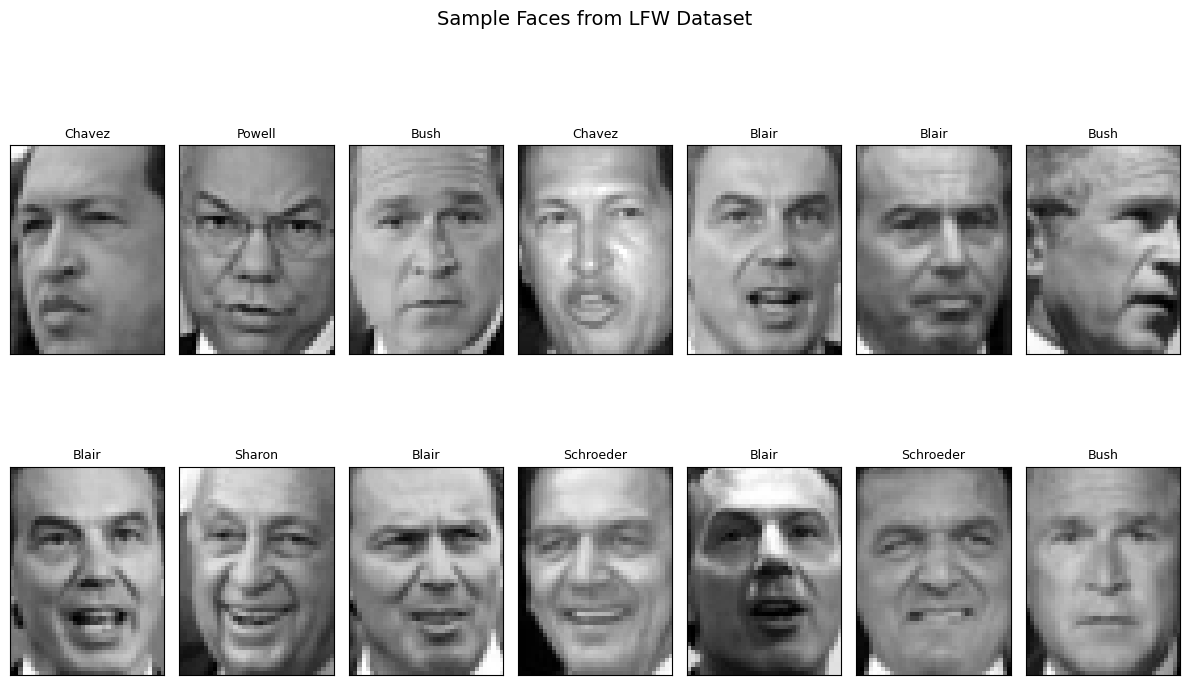

In [4]:
# checking how many images each person has
print("Number of images per person:")
for i, name in enumerate(lfw.target_names):
    count = np.sum(lfw.target == i)
    print(f"  {name}: {count} images")

# visualizing some sample faces
plt.figure(figsize=(12, 8))
for i in range(14):
    plt.subplot(2, 7, i+1)
    plt.imshow(lfw.images[i * 90], cmap='gray')
    plt.title(lfw.target_names[lfw.target[i * 90]].split()[-1], fontsize=9)
    plt.xticks([])
    plt.yticks([])
plt.suptitle("Sample Faces from LFW Dataset", fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
# preprocessing the data
x = lfw.images
y = lfw.target

# sklearn already gives pixel values between 0 and 1, so no need to divide by 255
print("Pixel range - Min:", x.min(), "Max:", x.max())

# adding channel dimension for CNN (grayscale = 1 channel)
x = x.reshape(-1, 50, 37, 1)

# splitting into train and test (80-20 split)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

Pixel range - Min: 0.0 Max: 1.0
Training data shape: (1030, 50, 37, 1)
Test data shape: (258, 50, 37, 1)


In [6]:
# building the CNN model for face recognition
model = models.Sequential([
    # first conv block - 32 filters
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(50, 37, 1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # second conv block - 64 filters
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # third conv block - 128 filters
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # dense layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    # output layer - 7 people so 7 neurons with softmax
    layers.Dense(7, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 50, 37, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 50, 37, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 25, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 25, 18, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 25, 18, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 9, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 9, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 9, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 9, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 487,815 (1.86 MB)

 Trainable params: 487,367 (1.86 MB)

 Non-trainable params: 448 (1.75 KB)

In [7]:
# data augmentation - important since we have limited training data
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
datagen.fit(x_train)

# compiling with adam optimizer
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# callbacks - reduce lr when accuracy plateaus and early stopping
lr_reducer = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=8, min_lr=1e-6, verbose=1, mode='max')
early_stop = EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True, verbose=1, mode='max')

# training with data augmentation
history = model.fit(datagen.flow(x_train, y_train, batch_size=32),
                    epochs=80,
                    validation_data=(x_test, y_test),
                    callbacks=[lr_reducer, early_stop])

Epoch 1/80
33/33 ━━━━━━━━━━━━━━━━━━━━ 12s 243ms/step - accuracy: 0.3204 - loss: 2.4162 - val_accuracy: 0.0543 - val_loss: 5.7201 - learning_rate: 0.0010
Epoch 2/80
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 173ms/step - accuracy: 0.3748 - loss: 1.7904 - val_accuracy: 0.0543 - val_loss: 9.0157 - learning_rate: 0.0010
Epoch 3/80
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 211ms/step - accuracy: 0.3942 - loss: 1.7771 - val_accuracy: 0.0543 - val_loss: 9.8916 - learning_rate: 0.0010
Epoch 4/80
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 167ms/step - accuracy: 0.4146 - loss: 1.6358 - val_accuracy: 0.0543 - val_loss: 9.9033 - learning_rate: 0.0010
Epoch 5/80
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 207ms/step - accuracy: 0.4515 - loss: 1.5896 - val_accuracy: 0.0543 - val_loss: 9.5651 - learning_rate: 0.0010
Epoch 6/80
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 162ms/step - accuracy: 0.4485 - loss: 1.5776 - val_accuracy: 0.0543 - val_loss: 9.1110 - learning_rate: 0.0010
Epoch 7/80
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 180ms/step - accuracy: 0.4553 - loss: 1.5390 -

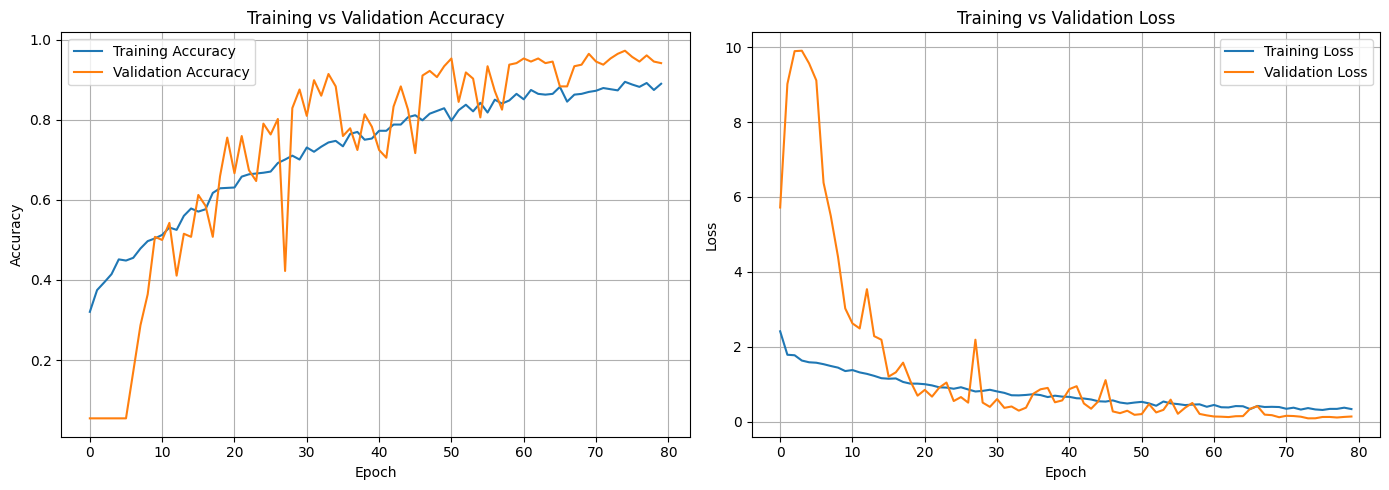


Final Training Accuracy: 89.03%
Final Validation Accuracy: 94.19%

✅ No overfitting detected - validation accuracy is >= training accuracy


In [8]:
# plotting accuracy and loss curves to check for overfitting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Training vs Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'], label='Training Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Training vs Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print("\nFinal Training Accuracy: {:.2f}%".format(history.history['accuracy'][-1] * 100))
print("Final Validation Accuracy: {:.2f}%".format(history.history['val_accuracy'][-1] * 100))

if history.history['val_accuracy'][-1] >= history.history['accuracy'][-1]:
    print("\n✅ No overfitting detected - validation accuracy is >= training accuracy")
else:
    gap = history.history['accuracy'][-1] - history.history['val_accuracy'][-1]
    if gap < 0.05:
        print("\n✅ No significant overfitting - gap is only {:.2f}%".format(gap * 100))
    else:
        print("\n⚠️ Possible overfitting - gap is {:.2f}%".format(gap * 100))

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9729 - loss: 0.0952

Test Accuracy: 97.29%
Test Loss: 0.0952
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step


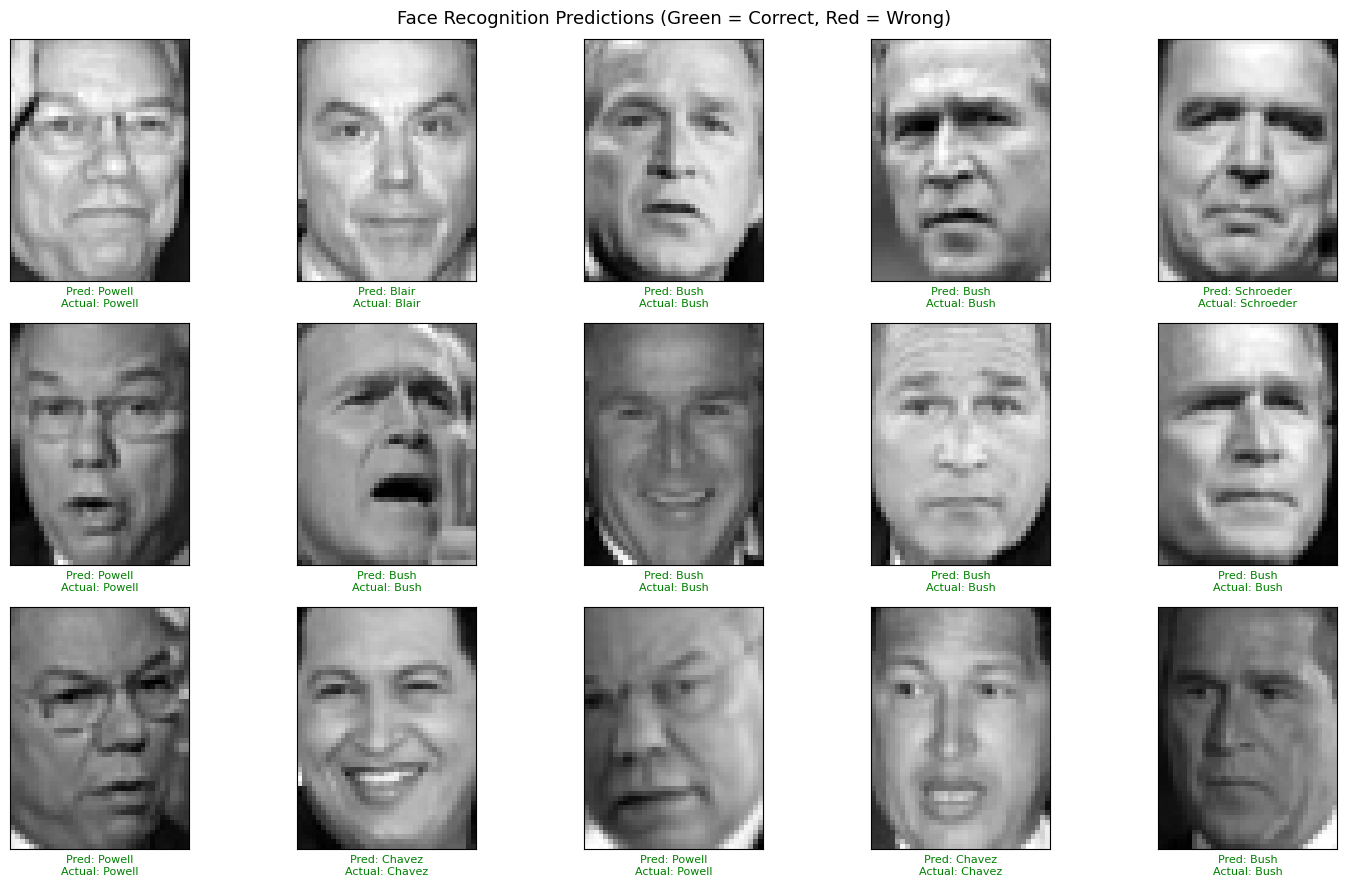

In [9]:
# evaluating on test data
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=1)
print("\nTest Accuracy: {:.2f}%".format(test_accuracy * 100))
print("Test Loss: {:.4f}".format(test_loss))

# visualizing some predictions
predictions = model.predict(x_test[:15])

plt.figure(figsize=(15, 9))
for i in range(15):
    plt.subplot(3, 5, i+1)
    plt.imshow(x_test[i].reshape(50, 37), cmap='gray')
    predicted = lfw.target_names[np.argmax(predictions[i])].split()[-1]
    actual = lfw.target_names[y_test[i]].split()[-1]
    color = 'green' if predicted == actual else 'red'
    plt.xlabel(f"Pred: {predicted}\nActual: {actual}", color=color, fontsize=8)
    plt.xticks([])
    plt.yticks([])
plt.suptitle("Face Recognition Predictions (Green = Correct, Red = Wrong)", fontsize=13)
plt.tight_layout()
plt.show()

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Classification Report:

              precision    recall  f1-score   support

      Sharon       0.88      0.94      0.91        16
      Powell       1.00      1.00      1.00        47
    Rumsfeld       0.92      0.96      0.94        24
        Bush       0.99      0.98      0.99       106
   Schroeder       0.96      1.00      0.98        22
      Chavez       1.00      0.93      0.96        14
       Blair       0.96      0.93      0.95        29

    accuracy                           0.97       258
   macro avg       0.96      0.96      0.96       258
weighted avg       0.97      0.97      0.97       258



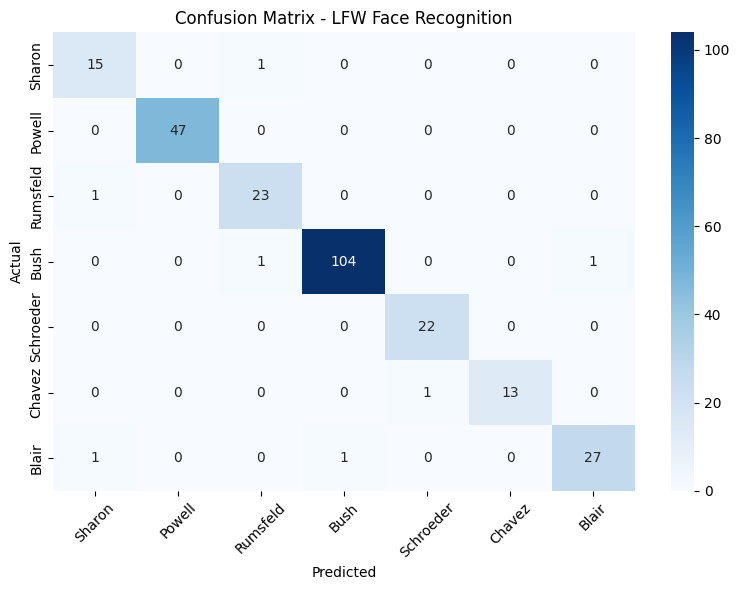


✅ Final Test Accuracy: 97.29% (Target was 90%)


In [10]:
# classification report and confusion matrix
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred = np.argmax(model.predict(x_test), axis=1)
short_names = [name.split()[-1] for name in lfw.target_names]

print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=short_names))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=short_names, yticklabels=short_names)
plt.title('Confusion Matrix - LFW Face Recognition')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n✅ Final Test Accuracy: {:.2f}% (Target was 90%)".format(test_accuracy * 100))